<a href="https://colab.research.google.com/github/1up9059/tareas_curso_NLP/blob/Tareas/Tarea3_Text_Classification_ES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 3 — Clasificación de texto (ES)

Implementación de modelos Naive Bayes, Regresión Logística y SVM para las siguientes fuentes:
1. `sentiment_analysis_dataset.csv`
2. `Spanish News Classification.csv`

Incluye preprocesamiento para español, TF–IDF, GridSearchCV, métricas (accuracy, macro-F1), matrices de confusión, curvas de aprendizaje y guardado de modelos.


In [12]:
!pip install scikit-learn unidecode matplotlib seaborn pandas numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 11.3 MB/s eta 0:00:00


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:

BASE_PATH = "/content/drive/MyDrive/source_NLP/inputs_NLP"
STOP_PATH = BASE_PATH + "/spanish_stop_words.txt"
SENT_PATH = BASE_PATH + "/sentiment_analysis_dataset.csv"
NEWS_PATH = BASE_PATH + "Spanish News Classification.csv"

In [15]:
# Imports y configuración
import re, string, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from unidecode import unidecode

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import joblib

import nltk
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('spanish')
from sklearn.utils.class_weight import compute_class_weight

sns.set(style="whitegrid")
RANDOM_STATE = 42


# Carga de stopwords de español

In [16]:
# Cargar stopwords personalizadas
try:
    with open(STOP_PATH, "r", encoding="utf-8") as f:
        custom_stopwords = set([w.strip().lower() for w in f if w.strip()])
    print("Stopwords cargadas:", len(custom_stopwords))

except FileNotFoundError:
    print(f"No se encontró '{STOP_PATH}'.")
    custom_stopwords = set()


Stopwords cargadas: 308


In [17]:
# Preprocesamiento en español
def clean_spanish_text(text, remove_numbers=False, do_stem=False, extra_stopwords=None):
  '''
  Definimos la función de limpieza con los siguiente parametros:
  text: el texto original a usar.
  remove_numbers: True, que elimina digitos del texto
  do_stem: False, para no aplicar steaming por default
  extra_stopwords: None, para no agregar mas stopwords por default, solo las del archivo
  '''
  t = str(text).lower()#Convertimos texto a minuscula

  #Eliminamos diacriticos y acentos, mantenemos ñ
  replacements = (("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),("ü","u"))
  for orig, repl in replacements:
    t = t.replace(orig, repl)
  #t = unidecode(t)
  t = re.sub(r"http\S+|www\.\S+|@\w+", " ", t)#Quitamos URLS
  #En este caso:
  #http\S+: “http” seguido de no-espacios (URLs).
  #www\.\S+: dominios que empiezan con www..
  #@\w+: menciones tipo @usuario.

  #Ahora eliminamos trasliteraciones ascii, usando la tabla translate,
  #Ademas quitamos los siguinos de puntuación como .,;:!?¿¡"()[]{}#@, etc
  t = t.translate(str.maketrans("", "", string.punctuation))

  #si remove_number True, eliminamos digitos
  if remove_numbers:
    t = re.sub(r"\d+", " ", t)
  #tokenizamos el texto haciendo split por espacio, suficiente para BOW
  tokens = t.split()

  #Ahora samos las stopwords cargadas desde el archivo, usando un set para busqueda rapida
  sw = set(custom_stopwords)

  #convertimos las stopwors a minusculas,  y las convertimos a un set nuevamente
  if extra_stopwords:
    sw |= set(map(str.lower, extra_stopwords))

  #Eliminamos las stopwords. Eliminamos todo token que no tengal len mayor a 1
  #esto permite mantener palabras como si y no
  tokens = [tok for tok in tokens if tok not in sw and len(tok) > 1]

  #Si do_stem True entonces hacemos steaming de las palabras para simplicar
  if do_stem and stemmer is not None:
    tokens = [stemmer.stem(tok) for tok in tokens]
  #Retornamos el texto limpio
  text = {"clean_text": " ".join(tokens), "tokens": tokens}
  return text


In [30]:
# Utilidades de evaluación
def evaluate_model(estimator, X_test, y_test, title="Resultados"):
    '''
    estimator: Es el modelo a usar, en este caso los modelos usados de Bayesiano Ingenuos
               Regresión logistica o SVM
    X_train, y_train: son los datos de entrenamiento
    X_test, y_test: Son los datos de prueba usados
    title: Es el titulo del grafico
    '''

    #usamos el modelo que se evalua al momento para predecir las etiquetas
    y_pred = estimator.predict(X_test)

    #Calculamos la proporcion de aciertos totales
    acc = accuracy_score(y_test, y_pred)

    #Calculamos F1-score clase por clase (usando el mismo peso para cada clase)
    f1m = f1_score(y_test, y_pred, average="macro")

    #Imprimimos resultados
    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f}\n")#a resultados a 4 decimales
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión — {title}")
    plt.xlabel("Predicho"); plt.ylabel("Real")
    plt.tight_layout(); plt.show()
    return { "acc":acc, "f1m":f1m}

In [25]:
def plot_learning_curves(estimator, X, y, cv=5, title="Curva de aprendizaje"):
  '''
  estimador: Es el modelo a usar, en este caso los modelos usados de Bayesiano Ingenuos
             Regresión logistica o SVM
  X: Son los datos de entrenamiento
  y: Son los datos de prueba usados
  cv:
  '''

  train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
      estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5),
      return_times=True, scoring="f1_macro", shuffle=True, random_state=RANDOM_STATE)

  plt.figure()
  plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="F1 macro (train)")
  plt.plot(train_sizes, test_scores.mean(axis=1), marker="o", label="F1 macro (val)")
  plt.title(title); plt.xlabel("Tamaño de entrenamiento"); plt.ylabel("F1 macro")
  plt.legend()
  plt.tight_layout();
  plt.show()

## 1) Dataset de Sentimiento — carga y limpieza


In [19]:
# Cargar CSV de sentimiento
df_sent = pd.read_csv(SENT_PATH, encoding="utf-8")
print(df_sent.head());
print("\nShape:", df_sent.shape); print("\nColumnas:", list(df_sent.columns))


             user                                               text  \
0      @erreborda               termine bien abrumado después de hoy   
1    @shpiderduck                                 me siento abrumado   
2     @Alex_R_art  Me siento un poco abrumado por la cantidad de ...   
3   @anggelinaa97  Salvador la única persona que no la ha abrumad...   
4  @diegoreyesvqz     Denme un helado o algo que ando full abrumado.   

                         date      emotion sentiment  
0   Jan 6, 2024 · 2:53 AM UTC  overwhelmed    scared  
1   Jan 6, 2024 · 2:35 AM UTC  overwhelmed    scared  
2  Jan 6, 2024 · 12:20 AM UTC  overwhelmed    scared  
3  Jan 5, 2024 · 10:38 PM UTC  overwhelmed    scared  
4   Jan 5, 2024 · 8:38 PM UTC  overwhelmed    scared  

Shape: (2590, 5)

Columnas: ['user', 'text', 'date', 'emotion', 'sentiment']


In [20]:
# Detectar columnas de texto y etiqueta
text_col_candidates = [c for c in df_sent.columns if c.lower() in ("text","texto","review","sentence","comment")]
label_col_candidates = [c for c in df_sent.columns if c.lower() in ("label","sentiment","target","polarity","categoria","clasificacion")]

text_col = text_col_candidates[0] if text_col_candidates else df_sent.columns[0]
label_col = label_col_candidates[0] if label_col_candidates else df_sent.columns[-1]

df_sent = df_sent[[text_col, label_col]].rename(columns={text_col:"text", label_col:"label"})
df_sent = df_sent.dropna(subset=["text","label"]).reset_index(drop=True)
print(df_sent["label"].value_counts())


label
peaceful    660
mad         530
powerful    420
sad         360
joyful      350
scared      270
Name: count, dtype: int64


In [21]:
# Preprocesar
df_sent["clean_text"] = df_sent["text"].apply(lambda s: clean_spanish_text(s, remove_numbers=True, do_stem=False)[ "tokens"])

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df_sent["clean_text"], df_sent["label"], test_size=0.2, random_state=42, stratify=df_sent["label"]
)
len(X_train_s), len(X_test_s)


(2072, 518)

In [22]:
df_sent.head()

,text,label,clean_text
0,termine bien abrumado después de hoy,scared,"[termine, bien, abrumado, despues, hoy]"
1,me siento abrumado,scared,"[siento, abrumado]"
2,Me siento un poco abrumado por la cantidad de ...,scared,"[siento, abrumado, cantidad, cosas, quiero, di..."
3,Salvador la única persona que no la ha abrumad...,scared,"[salvador, unica, persona, abrumado, versiones..."
4,Denme un helado o algo que ando full abrumado.,scared,"[denme, helado, ando, full, abrumado]"


In [57]:
# Pipelines y grids (Sentimiento)

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)

pipelines = {
    "MNB": Pipeline([("tfidf", tfidf), ("clf", MultinomialNB())]),
    "LR":  Pipeline([("tfidf", tfidf), ("clf", LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced"))]),
    "SVM": Pipeline([("tfidf", tfidf), ("clf", LinearSVC(class_weight="balanced"))])
}

param_grids = {
    "MNB": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__alpha":[0.1,0.5,1.0]},
    "LR":  {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__C":[0.1,1.0,3.0], "clf__penalty":["l2"], "clf__solver":["lbfgs","saga"]},
    "SVM": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__C":[0.5,1.0,2.0]}
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models_sent = {}
for name, pipe in pipelines.items():
    print(f"=== GridSearch {name} (sentimiento) ===")
    grid = GridSearchCV(pipe, param_grids[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid.fit(X_train_s, y_train_s)
    print("Mejores parámetros:", grid.best_params_)
    best_models_sent[name] = grid.best_estimator_


=== GridSearch MNB (sentimiento) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros: {'clf__alpha': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
=== GridSearch LR (sentimiento) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'clf__C': 3.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
=== GridSearch SVM (sentimiento) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros: {'clf__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}



Sentimiento — MNB
Accuracy: 0.6351 | Macro-F1: 0.6136

              precision    recall  f1-score   support

      joyful       0.68      0.46      0.55        70
         mad       0.65      0.77      0.71       106
    peaceful       0.65      0.73      0.69       132
    powerful       0.59      0.65      0.62        84
         sad       0.59      0.44      0.51        72
      scared       0.66      0.57      0.61        54

    accuracy                           0.64       518
   macro avg       0.64      0.61      0.61       518
weighted avg       0.64      0.64      0.63       518



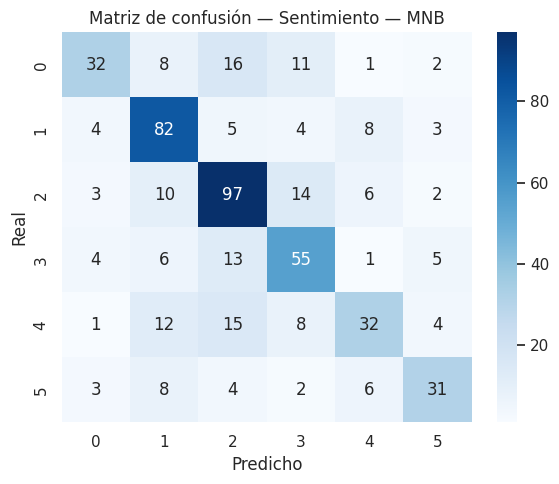

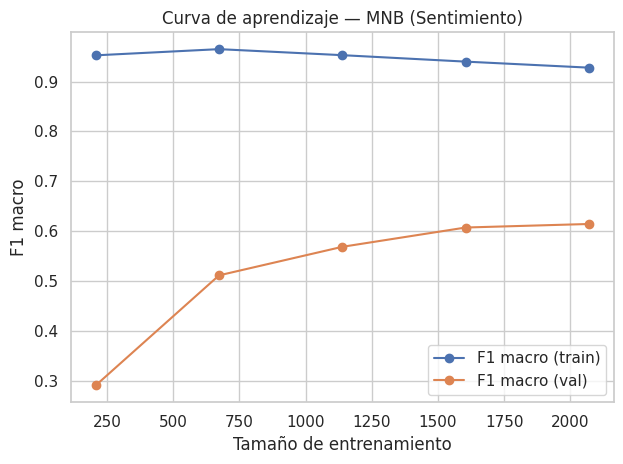


Sentimiento — LR
Accuracy: 0.7683 | Macro-F1: 0.7693

              precision    recall  f1-score   support

      joyful       0.83      0.69      0.75        70
         mad       0.77      0.83      0.80       106
    peaceful       0.79      0.76      0.77       132
    powerful       0.70      0.75      0.72        84
         sad       0.74      0.71      0.72        72
      scared       0.81      0.89      0.85        54

    accuracy                           0.77       518
   macro avg       0.77      0.77      0.77       518
weighted avg       0.77      0.77      0.77       518



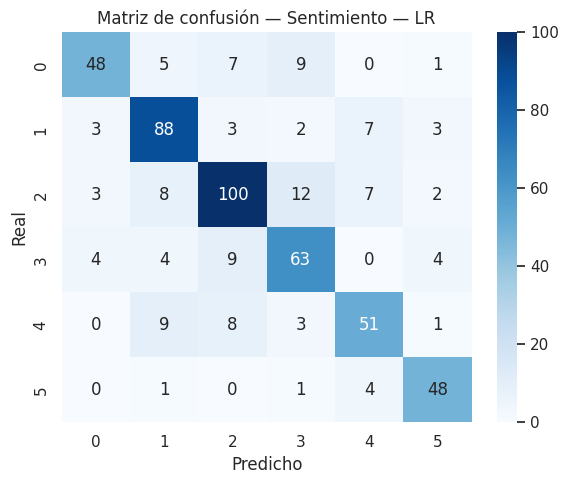

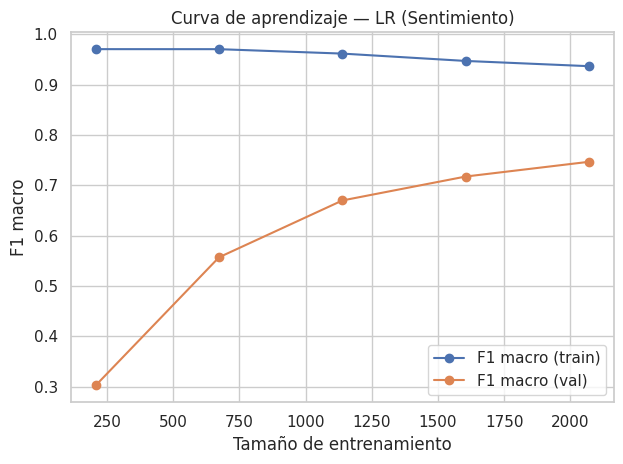


Sentimiento — SVM
Accuracy: 0.7857 | Macro-F1: 0.7855

              precision    recall  f1-score   support

      joyful       0.80      0.70      0.75        70
         mad       0.85      0.80      0.83       106
    peaceful       0.79      0.79      0.79       132
    powerful       0.71      0.79      0.75        84
         sad       0.74      0.76      0.75        72
      scared       0.81      0.89      0.85        54

    accuracy                           0.79       518
   macro avg       0.79      0.79      0.79       518
weighted avg       0.79      0.79      0.79       518



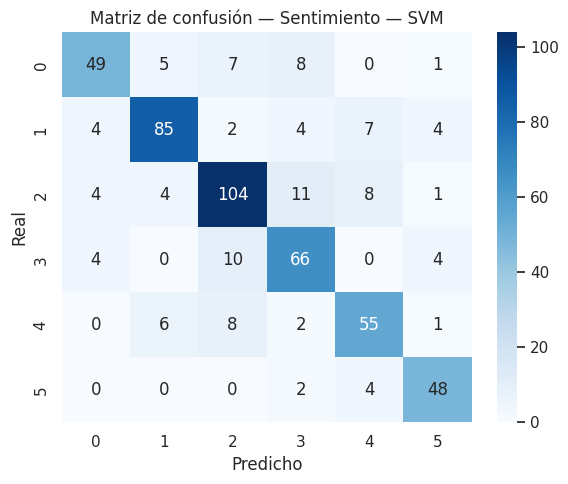

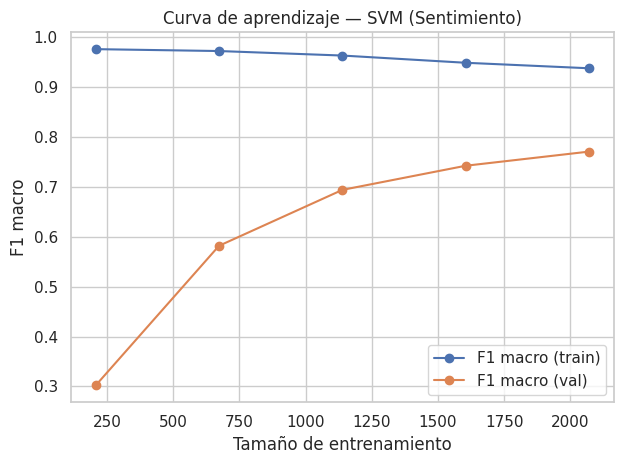

,Accuracy,F1_macro
MNB,0.635135,0.613604
LR,0.768340,0.769280
SVM,0.785714,0.785492


In [58]:
# Evaluación y curvas de aprendizaje (Sentimiento)
scores_sent = {}
for name, model in best_models_sent.items():
    model_results = evaluate_model(model, X_test_s, y_test_s, title=f"Sentimiento — {name}")
    acc = model_results['acc']
    f1m = model_results['f1m']
    scores_sent[name] = (acc, f1m)
    plot_learning_curves(model, pd.concat([X_train_s, X_test_s]), pd.concat([y_train_s, y_test_s]), cv=5, title=f"Curva de aprendizaje — {name} (Sentimiento)")

pd.DataFrame(scores_sent, index=["Accuracy","F1_macro"]).T


In [ ]:
# Top features (Sentimiento)
def show_top_features(clf_pipeline, top_k=20):
    vec = clf_pipeline.named_steps["tfidf"]
    clf = clf_pipeline.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    if hasattr(clf, "coef_"):
        for i, class_label in enumerate(clf.classes_):
            coefs = clf.coef_[i]
            top = np.argsort(coefs)[-top_k:]
            print(f"\nTop + para clase '{class_label}':")
            print(feature_names[top][::-1])
    elif hasattr(clf, "feature_log_prob_"):
        for i, class_label in enumerate(clf.classes_):
            top = np.argsort(clf.feature_log_prob_[i])[-top_k:]
            print(f"\nTop + para clase '{class_label}':")
            print(feature_names[top][::-1])
    else:
        print("Clasificador no soporta coeficientes.")

for name, model in best_models_sent.items():
    print(f"\n=== {name} ===")
    show_top_features(model, top_k=20)


In [ ]:
# Guardar modelos (Sentimiento)
os.makedirs("modelos_sent", exist_ok=True)
for name, model in best_models_sent.items():
    joblib.dump(model, f"modelos_sent/{name}_sent.joblib")
print("Modelos guardados en ./modelos_sent")


## 2) Dataset de Noticias — carga y limpieza


In [ ]:
# Cargar CSV de noticias
NEWS_PATH = "Spanish News Classification.csv"
df_news = pd.read_csv(NEWS_PATH, encoding="utf-8")
print(df_news.head()); print("\nShape:", df_news.shape); print("\nColumnas:", list(df_news.columns))


In [ ]:
# Detectar columnas
text_col_candidates = [c for c in df_news.columns if c.lower() in ("text","texto","headline","title","noticia")]
label_col_candidates = [c for c in df_news.columns if c.lower() in ("label","categoria","category","topic","seccion")]
text_col = text_col_candidates[0] if text_col_candidates else df_news.columns[0]
label_col = label_col_candidates[0] if label_col_candidates else df_news.columns[-1]

df_news = df_news[[text_col, label_col]].rename(columns={text_col:"text", label_col:"label"})
df_news = df_news.dropna(subset=["text","label"]).reset_index(drop=True)
print(df_news["label"].value_counts())


In [ ]:
# Preprocesar + split
df_news["clean_text"] = df_news["text"].apply(lambda s: clean_spanish_text(s, remove_numbers=True, do_stem=False))
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    df_news["clean_text"], df_news["label"], test_size=0.2, random_state=42, stratify=df_news["label"]
)
len(X_train_n), len(X_test_n)


In [ ]:
# Pipelines y grids (Noticias)
tfidf_n = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9)
pipelines_n = {
    "MNB": Pipeline([("tfidf", tfidf_n), ("clf", MultinomialNB())]),
    "LR":  Pipeline([("tfidf", tfidf_n), ("clf", LogisticRegression(max_iter=3000, n_jobs=-1, class_weight="balanced", multi_class="ovr"))]),
    "SVM": Pipeline([("tfidf", tfidf_n), ("clf", LinearSVC(class_weight="balanced"))])
}
param_grids_n = {
    "MNB": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,3,5], "clf__alpha":[0.1,0.5,1.0]},
    "LR":  {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,3,5], "clf__C":[0.5,1.0,3.0], "clf__penalty":["l2"], "clf__solver":["lbfgs","saga"]},
    "SVM": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,3,5], "clf__C":[0.5,1.0,2.0]}
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models_news = {}
for name, pipe in pipelines_n.items():
    print(f"=== GridSearch {name} (noticias) ===")
    grid = GridSearchCV(pipe, param_grids_n[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid.fit(X_train_n, y_train_n)
    print("Mejores parámetros:", grid.best_params_)
    best_models_news[name] = grid.best_estimator_


In [ ]:
# Evaluación y curvas (Noticias)
scores_news = {}
for name, model in best_models_news.items():
    acc, f1m = evaluate_model(model, X_train_n, X_test_n, y_train_n, y_test_n, title=f"Noticias — {name}")
    scores_news[name] = (acc, f1m)
    plot_learning_curves(model, pd.concat([X_train_n, X_test_n]), pd.concat([y_train_n, y_test_n]), cv=5, title=f"Curva de aprendizaje — {name} (Noticias)")

pd.DataFrame(scores_news, index=["Accuracy","F1_macro"]).T


In [ ]:
# Top features (Noticias)
for name, model in best_models_news.items():
    print(f"\n=== {name} ===")
    show_top_features(model, top_k=20)


In [ ]:
# Guardar modelos (Noticias)
os.makedirs("modelos_news", exist_ok=True)
for name, model in best_models_news.items():
    joblib.dump(model, f"modelos_news/{name}_news.joblib")
print("Modelos guardados en ./modelos_news")


## 3) Inferencia — carga de modelo y predicción
Ejemplo: cargar un modelo entrenado y predecir nuevas frases.


In [ ]:
def load_and_predict(model_path, texts):
    model = joblib.load(model_path)
    cleaned = [clean_spanish_text(t) for t in texts]
    return model.predict(cleaned)

# Ejemplo:
# preds = load_and_predict("modelos_sent/SVM_sent.joblib", ["Este producto es excelente", "No me gustó para nada"])
# preds


## 4) Sugerencias
- Experimenta con `do_stem=True` y ajuste de `min_df`, `max_df`, `ngram_range`.
- Si el PDF requiere SVM con *kernel* (RBF), cambia a `sklearn.svm.SVC` (más costoso con TF–IDF).
- Usa `class_weight="balanced"` cuando haya desbalance de clases.
- Guarda y comparte los modelos entrenados (`joblib`).
